# Analysis Summary: Image Contrast and Normalization

## 1. Objective
The goal of this experiment was to compare two images with identical structural content but significantly different contrast ranges (pixel intensity intervals) to understand how **Euclidean Distance** and **Normalization** affect image comparison.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import thisModule as tm
from PIL import Image, ImageEnhance

## 2. Data Generation & Loading
We generated synthetic grayscale images to simulate different contrast levels:


* using pillow we increase the contrast of an image to make two images with diffrent contrast but same content

In [ ]:
# Load image
img = Image.open("preprocessDB/0-255rice.png")

# Create enhancer
enhancer = ImageEnhance.Contrast(img)

# Increase contrast (2.0 = double, 1.0 = original, 0.5 = lower)
img_high = enhancer.enhance(2.0)

# Save result
img_high.save("preprocessDB/0-255rice_contrast_high.png")

* or we generate two images with diffrent pixel value intervales

In [ ]:
# --- PARAMETERS FOR LOW CONTRAST ---
height, width = 100, 100
min_intensity = 100  # The darkest point in the image
max_intensity = 150  # The brightest point in the image
# The difference between these is 50, which is low contrast compared to 255.

# 1. Create a 2D NumPy array (100x100 low-contrast gradient)
# Create a linear space from 100 to 150
first_contrast_gradient_1d = np.linspace(min_intensity, max_intensity, width, dtype=np.float32)
second_contrast_gradient_1d = np.linspace(200, 250, width, dtype=np.float32)

# Tile it vertically to create the 2D array
first_contrast_array = np.tile(first_contrast_gradient_1d, (height, 1))
second_contrast_array = np.tile(second_contrast_gradient_1d, (height, 1))

# Final cast to np.uint8 (0-255 integer type)
first_contrast_array = first_contrast_array.astype(np.uint8)
second_contrast_array = second_contrast_array.astype(np.uint8)

# 2. Save the image
plt.imsave("first_contrast_image.png", first_contrast_array, cmap='gray')
plt.imsave("second_contrast_image.png", second_contrast_array, cmap='gray')

* **Low Contrast Image:** Pixel intensities clustered between **100 and 150**.
* **High Contrast Image:** Pixel intensities clustered between **200 and 250**.

### Key Finding: Implicit Normalization
When loading PNG images using `matplotlib.pyplot.imread()`, we observed that the library **automatically normalizes** pixel values:
* **Input:** Integer values $[0, 255]$
* **Output:** Floating point values $[0.0, 1.0]$

For learning purposes and to perform accurate integer-based analysis, we successfully reversed this process:
$$\text{Image}_{int} = (\text{Image}_{float} \times 255).\text{astype}(\text{uint8})$$

now typically for the machine these are two diffrent images (diffrent pixel values) but for our eyes they are the same

## 3. Visualization Correction
We identified that `plt.imshow()` automatically scales the colormap to the min/max values of the specific array, making different contrast images look identical.
* **Solution:** We enforced a fixed global scale using parameters `vmin=0` and `vmax=255` (or `1.0` for floats) to visualize the true brightness differences.

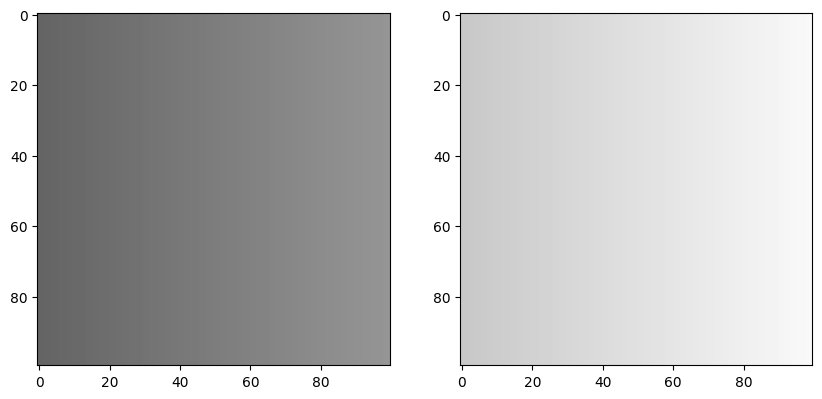

In [2]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
originalImage=tm.ImageAsArray("100-150-gray.png","preprocessDB")
originalImage=(originalImage*255).astype(np.uint8)
plt.imshow(originalImage, cmap='gray', vmin=0, vmax=255)
plt.subplot(1,2,2)
high_contrast_image=tm.ImageAsArray("200-250-gray.png","preprocessDB")
high_contrast_image=(high_contrast_image*255).astype(np.uint8)
plt.imshow(high_contrast_image, cmap='gray', vmin=0, vmax=255)

In [3]:
print(originalImage.shape)

(100, 100)


In [4]:
print(originalImage[0, :5])
print(high_contrast_image[0, :5])

[100 100 101 101 102]
[200 200 201 201 202]


In [5]:
print(originalImage.min(), originalImage.max())
print(high_contrast_image.min(), high_contrast_image.max())

100 150
200 250


## 4.Quantitative Analysis: Euclidean Distance

To strictly quantify the dissimilarity between the **Original Image ($A$)** and the **High Contrast Image ($B$)**, we utilized the **Euclidean Distance** metric.

### Method
1.  **Flattening:** The 2D image matrices (shape $100 \times 100$) were flattened into 1D vectors (length $10,000$).
2.  **Calculation:** We calculated the Euclidean distance between these two vectors using the formula:

$$d(A, B) = \sqrt{\sum_{i=1}^{N} (A_i - B_i)^2}$$

### Interpretation
The resulting distance measures the magnitude of difference in intensity space.
* A distance of **0** would imply the images are identical.
* A **higher distance** indicates a significant shift in contrast, even if the structural content (shapes and edges) remains the same.

## 5. Experiment: The Necessity of Normalization

### The Problem: Scale Sensitivity
If we calculate the **Euclidean Distance** using the raw pixel intensities (e.g., range $100-150$ vs. $200-250$), we obtain a very large distance value.
* **Implication:** A large distance typically suggests that two images are completely different.
* **Reality:** In this case, the images are structurally identical; only their brightness scale is different. The raw metric is biased by the absolute offset in values.

### The Solution: Normalization (Min-Max Scaling)
To fix this bias and compare the *structure* rather than the *absolute brightness*, we normalize both images to the same standard range $[0, 1]$.

$$\text{Pixel}_{norm} = \frac{\text{Pixel}_{raw} - \text{min}}{\text{max} - \text{min}}$$

*(Or simply dividing by 255 if the theoretical range is known).*

### Comparison
We will now calculate and compare the two distances to verify that normalization allows for a fairer comparison:
1.  **Distance (Raw):** Calculated on original integer arrays.
2.  **Distance (Normalized):** Calculated after scaling both images to $[0, 1]$.

In [6]:
originalDistance = tm.EuclideanDistance(originalImage, high_contrast_image)
print("Original Distance:", originalDistance)

Original Distance: 400.0


**Observation:** This large value ($400.0$) confirms that the raw Euclidean distance is highly sensitive to global intensity shifts. Even though the images represent the same visual content, the metric suggests a significant difference solely due to the pixel value offsets (contrast).

In [7]:
NormalizedOriginalImage = tm.normalizeImage(originalImage)
NormalizedHighContrastImage = tm.normalizeImage(high_contrast_image)

In [8]:
print(NormalizedOriginalImage[0, :5])
print(NormalizedHighContrastImage[0, :5])

[0.   0.   0.02 0.02 0.04]
[0.   0.   0.02 0.02 0.04]


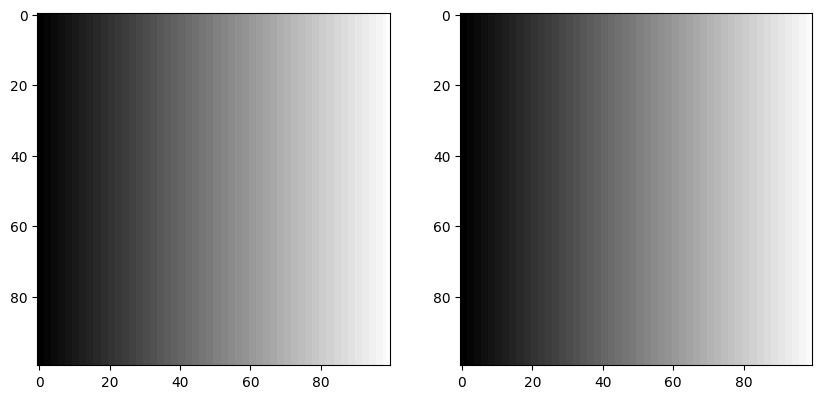

In [9]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(NormalizedOriginalImage, cmap='gray', vmin=0, vmax=1)
plt.subplot(1,2,2)
plt.imshow(NormalizedHighContrastImage, cmap='gray', vmin=0, vmax=1)

#### after normalizing we calculate the new distance

In [10]:
newDistance = tm.EuclideanDistance(NormalizedOriginalImage, NormalizedHighContrastImage)
print("New Distance after normalization:", newDistance)

New Distance after normalization: 0.0


### 6. Final Comparison & Conclusion

We compared the Euclidean Distance before and after applying Min-Max Normalization to the images.

**Results:**
* **Original Distance (Raw):** `400.0`
* **New Distance (Normalized):** `0.0`

### Interpretation
1.  **The False Positive:** The raw distance of **400.0** suggested the images were significantly different. However, this was misleading; it was purely an artifact of the pixel intensity offset (the "brightness" shift).
2.  **The Correction:** After normalizing both images to the same relative scale ($0-1$), the distance dropped to **0.0**.
3.  **Conclusion:** A distance of **0.0** confirms that the two images are **structurally identical**. Normalization successfully removed the bias caused by differing contrast ranges, allowing the metric to correctly identify that the underlying patterns were the same.

In [11]:
print("originalDistance:", originalDistance ,">>>>> newDistance:", newDistance)

originalDistance: 400.0 >>>>> newDistance: 0.0


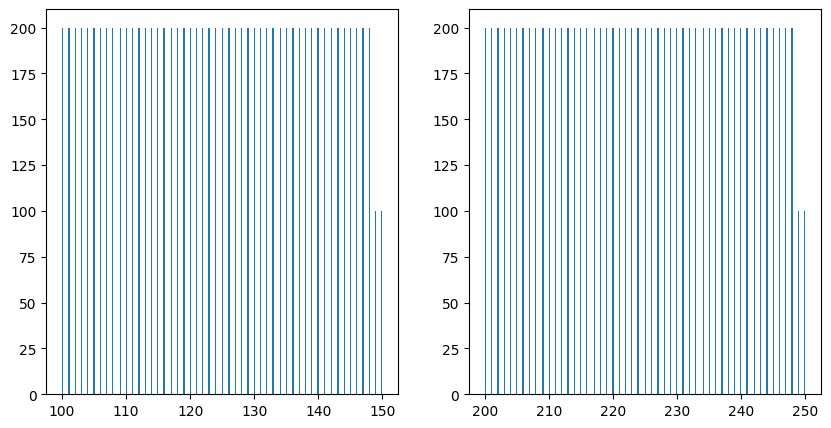

In [12]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(originalImage.flatten(),bins=256);
plt.subplot(1,2,2)
plt.hist(high_contrast_image.flatten(),bins=256);

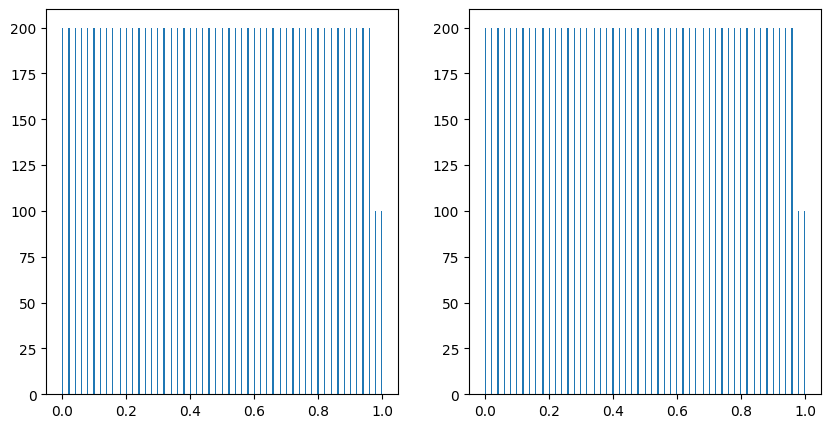

In [13]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(NormalizedOriginalImage.flatten(),bins=256);
plt.subplot(1,2,2)
plt.hist(NormalizedHighContrastImage.flatten(),bins=256);

we can try with real images

In [14]:
img1 = plt.imread("preprocessDB/mandi.tif")
img2 = plt.imread("preprocessDB/mandi_contrast_high.tif")

In [16]:
testDist = tm.EuclideanDistance(img1, img2)
print("Distance before normalization:", testDist)

Distance before normalization: 24096.90148131083


In [17]:
testDistNorm = tm.EuclideanDistance(tm.normalizeImage(img1), tm.normalizeImage(img2))
print("Distance after normalization:", testDistNorm)

Distance after normalization: 285.43660747320615
